*Instalasi & Import Library*
Deskripsi:
- Langkah awal adalah menginstal dan mengimpor library yang dibutuhkan untuk mengambil, memproses, dan memvisualisasikan data spasial.

Fungsi Python:
1. pip install ... : Instalasi library dari terminal.
2. import ... : Mengimpor library ke script/notebook.

In [1]:
import requests
import folium
import geopandas as gpd
from shapely.geometry import shape
from pyproj import CRS
import json
import os

1️⃣ Judul: Pengambilan Data GeoJSON dari API MapID

- Deskripsi:
1. Mengambil data spasial (GeoJSON) dari berbagai endpoint API MapID untuk setiap variabel analisis.

- Fungsi:
1. Mendownload data GeoJSON dari API MapID untuk setiap modul/variabel.

# Lengkapi dictionary URL
urls = {
    "tingkat_polusi": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984a42396de9425652debb4&project_id=697e526a949d92a51f0b4816',
    "harga_lahan": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984a994bbaa47f3ce684277&project_id=697e526a949d92a51f0b4816',
    "fasilitas_transportasi": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984aa4296de9425652ebfad&project_id=697e526a949d92a51f0b4816',
    "fasilitas_pendidikan": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984ac32bbaa47f3ce68c2f2&project_id=697e526a949d92a51f0b4816',
    "luas_lahan": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984ac502d33abfe646477d1&project_id=697e526a949d92a51f0b4816',
    "ketersediaan_air_bersih": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984ac7abbaa47f3ce68c40d&project_id=697e526a949d92a51f0b4816',
    "risiko_banjir": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984ac9dbbaa47f3ce68dc4d&project_id=697e526a949d92a51f0b4816',
    "kepadatan_penduduk": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984acd196de9425652f4015&project_id=697e526a949d92a51f0b4816'
}

In [2]:
import requests
import geopandas as gpd

# Lengkapi dictionary URL
urls = {
    "tingkat_polusi": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984a42396de9425652debb4&project_id=697e526a949d92a51f0b4816',
    "harga_lahan": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984a994bbaa47f3ce684277&project_id=697e526a949d92a51f0b4816',
    "fasilitas_transportasi": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984aa4296de9425652ebfad&project_id=697e526a949d92a51f0b4816',
    "fasilitas_pendidikan": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984ac32bbaa47f3ce68c2f2&project_id=697e526a949d92a51f0b4816',
    "luas_lahan": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984ac502d33abfe646477d1&project_id=697e526a949d92a51f0b4816',
    "ketersediaan_air_bersih": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984ac7abbaa47f3ce68c40d&project_id=697e526a949d92a51f0b4816',
    "risiko_banjir": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984ac9dbbaa47f3ce68dc4d&project_id=697e526a949d92a51f0b4816',
    "kepadatan_penduduk": 'https://geoserver.mapid.io/layers_new/get_layer?api_key=70b6758f25e94e6a849a32d935bce369&layer_id=6984acd196de9425652f4015&project_id=697e526a949d92a51f0b4816'
}


2️⃣ Membaca & Mengonversi Data GeoJSON ke GeoDataFrame

- Deskripsi:
1. Mengubah data GeoJSON hasil request API menjadi GeoDataFrame agar mudah dianalisis secara spasial.

- Fungsi:
1. Membaca data GeoJSON dari API dan mengubahnya menjadi GeoDataFrame menggunakan GeoPandas.

In [3]:
import geopandas as gpd

def get_gdf_from_api(url):
    response = requests.get(url)
    if response.status_code == 200:
        geojson = response.json()
        gdf = gpd.GeoDataFrame.from_features(geojson['features'])
        print(f"Berhasil mengambil data dari {url.split('&layer_id=')[1][:10]}...")
        return gdf
    else:
        print(f"Gagal mengambil data dari {url}")
        return gpd.GeoDataFrame()

# Membaca semua data ke dalam dictionary GeoDataFrame
gdfs = {}
for key, url in urls.items():
    gdfs[key] = get_gdf_from_api(url)

Berhasil mengambil data dari 6984a42396...
Berhasil mengambil data dari 6984a994bb...
Berhasil mengambil data dari 6984aa4296...
Berhasil mengambil data dari 6984ac32bb...
Berhasil mengambil data dari 6984ac502d...
Berhasil mengambil data dari 6984ac7abb...
Berhasil mengambil data dari 6984ac9dbb...
Berhasil mengambil data dari 6984acd196...


3️⃣ Pemeriksaan & Penyesuaian Data (Null & CRS)

- Deskripsi:
1. Memastikan semua data tidak memiliki nilai null pada kolom utama dan CRS konsisten (misal: EPSG:4326).

- Fungsi:
1. Mengisi nilai null dengan default.
2. Menyesuaikan CRS agar overlay berjalan lancar.

In [4]:
from pyproj import CRS

for key, gdf in gdfs.items():
    # Isi null dengan default (0 atau 'TIDAK DIKETAHUI')
    for col in gdf.columns:
        if gdf[col].dtype == 'O':
            gdf[col] = gdf[col].fillna('TIDAK DIKETAHUI')
        else:
            gdf[col] = gdf[col].fillna(0)
    # Set CRS ke EPSG:4326 jika belum
    if gdf.crs is None or gdf.crs.to_epsg() != 4326:
        gdf.set_crs(epsg=4326, inplace=True)
    gdfs[key] = gdf
print("Semua data sudah dicek dan disesuaikan.")


Semua data sudah dicek dan disesuaikan.


4️⃣ Visualisasi Data Spasial Setiap Variabel

- Deskripsi:
1. Menampilkan peta setiap variabel menggunakan Folium untuk eksplorasi awal.

- Fungsi:
1. Membuat peta interaktif untuk tiap variabel.

In [5]:
import folium

for key, gdf in gdfs.items():
    m = folium.Map(location=[-6.23, 106.83], zoom_start=13)
    folium.GeoJson(gdf).add_to(m)
    folium.LayerControl().add_to(m)
    display(m)  
    print(f"Peta untuk variabel: {key}")


Peta untuk variabel: tingkat_polusi


Peta untuk variabel: harga_lahan


Peta untuk variabel: fasilitas_transportasi


Peta untuk variabel: fasilitas_pendidikan


Peta untuk variabel: luas_lahan


Peta untuk variabel: ketersediaan_air_bersih


Peta untuk variabel: risiko_banjir


Peta untuk variabel: kepadatan_penduduk


In [20]:
gdfs['fasilitas_pendidikan'].head(1)

,geometry,DEKAT_PENDIDIKAN
0,"POLYGON ((106.88 -6.28, 106.89 -6.28, 106.89 -...",TIDAK


5️⃣ Overlay/Intersect Data Spasial Multi-Variabel

- Deskripsi:
1. Menggabungkan seluruh layer spasial berdasarkan geometri yang saling tumpang tindih (intersect) untuk menghasilkan satu GeoDataFrame komposit.

- Fungsi:
1. Melakukan overlay/intersect antar semua variabel sehingga setiap area memiliki seluruh atribut gabungan.

In [6]:
import geopandas as gpd

# Pastikan kolom 'ID' dihapus/rename agar tidak error saat overlay
for key in gdfs.keys():
    if 'ID' in gdfs[key].columns:
        gdfs[key] = gdfs[key].drop(columns=['ID'])

# List GeoDataFrame yang akan di-intersect (urutkan sesuai kebutuhan analisis)
gdf_list = [
    gdfs['kepadatan_penduduk'],
    gdfs['risiko_banjir'],
    gdfs['ketersediaan_air_bersih'],
    gdfs['luas_lahan'],
    gdfs['fasilitas_pendidikan'],
    gdfs['fasilitas_transportasi'],
    gdfs['harga_lahan'],
    gdfs['tingkat_polusi']
]

# Fungsi overlay/intersect berurutan
def overlay_multiple(gdf_list):
    result = gdf_list[0]
    for gdf in gdf_list[1:]:
        if not gdf.empty:
            result = gpd.overlay(result, gdf, how='intersection')
            result = result[result.is_valid]
    return result

gdf_intersect = overlay_multiple(gdf_list)
print(f"Jumlah area hasil intersect: {len(gdf_intersect)}")


Jumlah area hasil intersect: 5


In [7]:
print("Kolom hasil intersect:", gdf_intersect.columns)


Kolom hasil intersect: Index(['KEPADATAN', 'RISIKO_BANJIR', 'AIR_BERSIH', 'LUAS_LAHAN',
       'DEKAT_PENDIDIKAN', 'DEKAT_TRANSPORTASI', 'HARGA_LAHAN',
       'TINGKAT_POLUSI', 'geometry'],
      dtype='object')


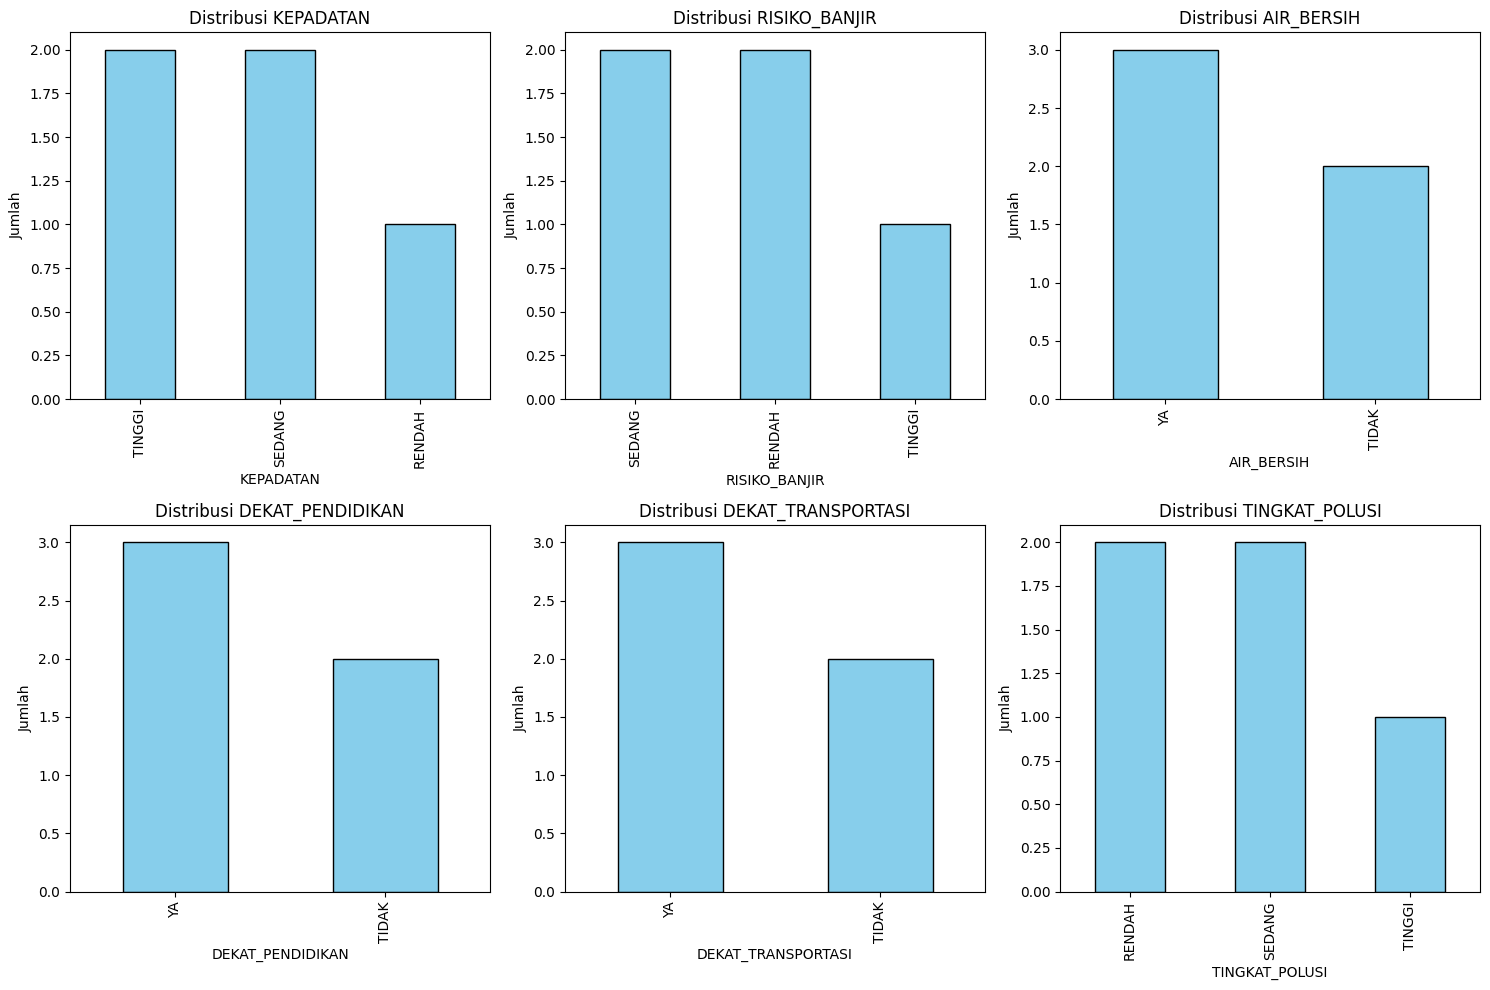

In [8]:
import matplotlib.pyplot as plt

kategori_cols = [
    'KEPADATAN', 'RISIKO_BANJIR', 'AIR_BERSIH',
    'DEKAT_PENDIDIKAN', 'DEKAT_TRANSPORTASI', 'TINGKAT_POLUSI'
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(kategori_cols, 1):
    if col in gdf_intersect.columns:
        plt.subplot(2, 3, i)
        gdf_intersect[col].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
        plt.title(f'Distribusi {col}')
        plt.xlabel(col)
        plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()


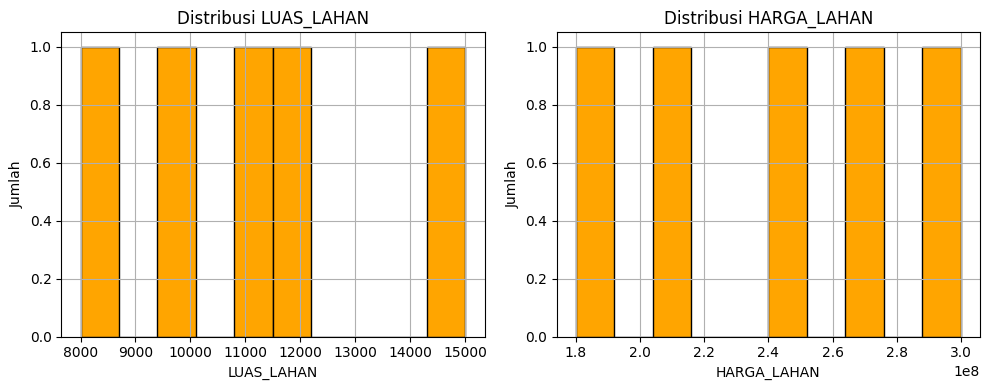

In [9]:
numerik_cols = []
if 'LUAS_LAHAN' in gdf_intersect.columns:
    numerik_cols.append('LUAS_LAHAN')
if 'HARGA_LAHAN' in gdf_intersect.columns:
    numerik_cols.append('HARGA_LAHAN')

plt.figure(figsize=(10, 4))
for i, col in enumerate(numerik_cols, 1):
    plt.subplot(1, len(numerik_cols), i)
    gdf_intersect[col].hist(bins=10, color='orange', edgecolor='black')
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()


6️⃣ Skoring & Klasifikasi Kesesuaian Lokasi

- Deskripsi:
1. Memberikan skor pada setiap variabel, menghitung skor total, dan mengklasifikasikan tingkat kesesuaian lokasi.

- Fungsi:
1. Menambahkan kolom skor untuk setiap variabel.
2. Menjumlahkan skor total dan mengklasifikasikan hasilnya.

In [10]:
import pandas as pd

def skoring(row):
    skor = 0
    # Aturan skoring (bisa disesuaikan)
    skor += {"RENDAH": 1, "SEDANG": 2, "TINGGI": 3}.get(str(row.get("KEPADATAN", "")).upper(), 0)
    skor += {"RENDAH": 3, "SEDANG": 2, "TINGGI": 1}.get(str(row.get("RISIKO_BANJIR", "")).upper(), 0)
    skor += 3 if str(row.get("AIR_BERSIH", "")).upper() == "YA" else 1
    luas = row.get("LUAS_LAHAN", 0)
    skor += 3 if luas > 10000 else 2 if luas > 5000 else 1
    skor += 2 if str(row.get("DEKAT_PENDIDIKAN", "")).upper() == "YA" else 1
    skor += 2 if str(row.get("DEKAT_TRANSPORTASI", "")).upper() == "YA" else 1
    harga = row.get("HARGA_LAHAN", 0)
    skor += 3 if harga < 200000000 else 2 if harga < 275000000 else 1
    skor += {"RENDAH": 3, "SEDANG": 2, "TINGGI": 1}.get(str(row.get("TINGKAT_POLUSI", "")).upper(), 0)
    return skor

# Hitung skor total untuk setiap baris
gdf_intersect['SKOR_TOTAL'] = gdf_intersect.apply(skoring, axis=1)

# Klasifikasi kesesuaian lokasi
gdf_intersect['KESESUAIAN'] = pd.cut(
    gdf_intersect['SKOR_TOTAL'],
    bins=[0, 10, 16, 24],  # Interval: 0-10=RENDAH, 11-16=SEDANG, 17-24=TINGGI
    labels=['RENDAH', 'SEDANG', 'TINGGI'],
    include_lowest=True
)

# Lihat hasil 10 baris pertama
print(gdf_intersect[['SKOR_TOTAL', 'KESESUAIAN']].head(10))


   SKOR_TOTAL KESESUAIAN
0          15     SEDANG
1          18     TINGGI
2          15     SEDANG
3          14     SEDANG
4          20     TINGGI


7️⃣ Visualisasi Hasil Skoring & Kesesuaian Lokasi

- Deskripsi:
1. Menampilkan hasil akhir skoring dan klasifikasi kesesuaian lokasi pada peta interaktif.

- Fungsi:
1. Memvisualisasikan area hasil intersect beserta skor dan kelas kesesuaian menggunakan Folium.

In [11]:
import folium
import branca.colormap as cm

# Mapping label ke warna
label_to_color = {'RENDAH': 'red', 'SEDANG': 'orange', 'TINGGI': 'green'}

# Fungsi style untuk seluruh GeoDataFrame
def style_function(feature):
    kategori = feature['properties'].get('KESESUAIAN', 'gray')
    return {
        'fillColor': label_to_color.get(kategori, 'gray'),
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.5
    }

# Buat peta
m = folium.Map(location=[-6.23, 106.83], zoom_start=13)

# Tambahkan seluruh GeoDataFrame sekaligus
folium.GeoJson(
    gdf_intersect,
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(fields=['SKOR_TOTAL', 'KESESUAIAN'])
).add_to(m)

# Colormap manual (opsional)
colormap = cm.StepColormap(
    colors=['red', 'orange', 'green'],
    vmin=0, vmax=2,
    index=[0, 1, 2, 3],
    caption='Kesesuaian Lokasi'
)
colormap.add_to(m)

m  


8️⃣ Menyimpan Hasil Analisis ke File GeoJSON

- Deskripsi:
1. Menyimpan hasil akhir (GeoDataFrame hasil intersect + skoring) ke file GeoJSON untuk dokumentasi atau analisis lanjutan.

- Fungsi:
1. Ekspor hasil analisis ke file GeoJSON.

In [12]:
# import os

# output_dir = r"D:\Users\kkb24057\Downloads\MAPID WebGIS Development Bootcamp Batch 2\MAPID_WEBGIS_BOOTCAMP_TRIAL\labs"
# os.makedirs(output_dir, exist_ok=True)
# output_path = os.path.join(output_dir, "hasil_analisis_lokasi.geojson")
# gdf_intersect.to_file(output_path, driver='GeoJSON')
# print(f"Hasil analisis berhasil disimpan di: {output_path}")


9️⃣ Judul: Analisis Statistik & Eksplorasi Data

- Deskripsi:
1. Melakukan analisis statistik deskriptif, korelasi, dan eksplorasi distribusi hasil skoring.

- Fungsi:
1. Statistik deskriptif, distribusi kategori, dan korelasi antar variabel.

In [13]:
# # Statistik deskriptif
# print("Statistik Deskriptif Numerik:")
# print(gdf_intersect[['SKOR_TOTAL', 'LUAS_LAHAN', 'HARGA_LAHAN']].describe())

# print("\nDistribusi Kategori Kesesuaian:")
# print(gdf_intersect['KESESUAIAN'].value_counts())

# print("\nKorelasi antar variabel numerik:")
# print(gdf_intersect[['SKOR_TOTAL', 'LUAS_LAHAN', 'HARGA_LAHAN']].corr())


1️⃣0️⃣ Judul: Menentukan & Visualisasi Lokasi Optimal

- Deskripsi:
1. Menemukan area dengan skor total tertinggi (lokasi paling optimal) dan menampilkan atribut serta visualisasinya di peta.

- Fungsi:
1. Filter lokasi dengan skor tertinggi.
2. Tampilkan atribut lokasi optimal.
3. Visualisasi lokasi optimal di peta interaktif.

In [14]:
# Temukan skor total maksimum
max_skor = gdf_intersect['SKOR_TOTAL'].max()

# Filter lokasi dengan skor total maksimum
lokasi_optimal = gdf_intersect[gdf_intersect['SKOR_TOTAL'] == max_skor]
print(f"Jumlah lokasi optimal (skor tertinggi): {len(lokasi_optimal)}")
print("Atribut lokasi optimal:")
print(lokasi_optimal[['SKOR_TOTAL', 'KEPADATAN', 'RISIKO_BANJIR', 'AIR_BERSIH', 
                     'LUAS_LAHAN', 'DEKAT_PENDIDIKAN', 'DEKAT_TRANSPORTASI', 
                     'HARGA_LAHAN', 'TINGKAT_POLUSI']])


Jumlah lokasi optimal (skor tertinggi): 1
Atribut lokasi optimal:
   SKOR_TOTAL KEPADATAN RISIKO_BANJIR AIR_BERSIH  LUAS_LAHAN DEKAT_PENDIDIKAN  \
4          20    TINGGI        RENDAH         YA       12000               YA   

  DEKAT_TRANSPORTASI  HARGA_LAHAN TINGKAT_POLUSI  
4                 YA    250000000         SEDANG  


In [15]:
import folium

# Buat peta
m_optimal = folium.Map(location=[-6.23, 106.83], zoom_start=13)

# Fungsi style khusus lokasi optimal
def style_optimal(feature):
    return {
        'fillColor': 'lime',
        'color': 'blue',
        'weight': 3,
        'fillOpacity': 0.7
    }

# Tambahkan seluruh GeoDataFrame lokasi optimal sekaligus
folium.GeoJson(
    lokasi_optimal,
    style_function=style_optimal,
    tooltip=folium.GeoJsonTooltip(fields=['SKOR_TOTAL', 'KESESUAIAN'])
).add_to(m_optimal)

folium.LayerControl().add_to(m_optimal)
m_optimal  # Tampilkan di Jupyter Notebook


1️⃣1️⃣ Analisis Lanjutan & Insight Lokasi Optimal

- Deskripsi:
1. Analisis lebih lanjut seperti distribusi spasial lokasi optimal, buffer zona pengaruh, atau statistik tambahan.

- Fungsi:
1. Membuat buffer dari lokasi optimal.
2. Statistik tambahan lokasi optimal.

In [16]:
# Buffer 500 meter dari lokasi optimal (sekitar 0.005 derajat pada EPSG:4326)
lokasi_optimal['buffer_500m'] = lokasi_optimal.geometry.buffer(0.005)

# Statistik tambahan
print("Statistik lokasi optimal:")
print(lokasi_optimal.describe(include='all'))


Statistik lokasi optimal:
       KEPADATAN RISIKO_BANJIR AIR_BERSIH  LUAS_LAHAN DEKAT_PENDIDIKAN  \
count          1             1          1         1.0                1   
unique         1             1          1         NaN                1   
top       TINGGI        RENDAH         YA         NaN               YA   
freq           1             1          1         NaN                1   
mean         NaN           NaN        NaN     12000.0              NaN   
std          NaN           NaN        NaN         NaN              NaN   
min          NaN           NaN        NaN     12000.0              NaN   
25%          NaN           NaN        NaN     12000.0              NaN   
50%          NaN           NaN        NaN     12000.0              NaN   
75%          NaN           NaN        NaN     12000.0              NaN   
max          NaN           NaN        NaN     12000.0              NaN   

       DEKAT_TRANSPORTASI  HARGA_LAHAN TINGKAT_POLUSI  \
count                   1   

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24400\3242774883.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lokasi_optimal['buffer_500m'] = lokasi_optimal.geometry.buffer(0.005)
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [17]:
# import geopandas as gpd
# import os
# from shapely.geometry import Polygon, MultiPolygon

# # Pastikan buffer jadi geometry utama
# buffer_gdf = lokasi_optimal.copy()
# buffer_gdf = buffer_gdf.set_geometry(buffer_gdf['buffer_500m'])

# # Hapus kolom geometry lain jika masih ada
# if 'geometry' in buffer_gdf.columns and buffer_gdf.geometry.name != 'geometry':
#     buffer_gdf = buffer_gdf.drop(columns=['geometry'])

# # Filter hanya geometry valid dan bertipe Polygon/MultiPolygon
# buffer_gdf = buffer_gdf[buffer_gdf.geometry.notnull()]
# buffer_gdf = buffer_gdf[buffer_gdf.geometry.apply(lambda x: x.is_valid and isinstance(x, (Polygon, MultiPolygon)))]

# # Ekspor ke GeoJSON
# output_dir = r"D:\Users\kkb24057\Downloads\MAPID WebGIS Development Bootcamp Batch 2\MAPID_WEBGIS_BOOTCAMP_TRIAL\labs"
# os.makedirs(output_dir, exist_ok=True)
# output_path = os.path.join(output_dir, "buffer_lokasi_optimal.geojson")

# buffer_gdf.to_file(output_path, driver='GeoJSON')
# print(f"Buffer lokasi optimal berhasil diekspor ke: {output_path}")


*Buka GEO MapID Editor*

1. Pada tahap ini sekarang kamu coba upload hasil geojson tersebut ke GEO MapID Editor agar menjadi API